In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [10]:
import os
import pandas as pd

# Search common Windows Desktop locations for Lenovo
user_home = r"C:\Users\Lenovo"
search_paths = [
    os.path.join(user_home, "OneDrive", "Desktop", "heart.csv"),
    os.path.join(user_home, "OneDrive", "Desktop", "heart.csv.csv"),
    os.path.join(user_home, "Desktop", "heart.csv.csv"),
    os.path.join(user_home, "Downloads", "heart.csv"),
    os.path.join(user_home, "Downloads", "heart.csv.csv"),
]

found_path = None
for path in search_paths:
    if os.path.exists(path):
        found_path = path
        break

if found_path:
    print(f"File found at: {found_path}")
    df = pd.read_csv(found_path)
    print("\nFirst Five Records:")
    print(df.head())
else:
    # If not found in common paths, list actual files on Desktop & OneDrive Desktop
    print("Could not find file in standard paths. Checking your desktop folders:\n")
    for d in [os.path.join(user_home, "Desktop"), os.path.join(user_home, "OneDrive", "Desktop")]:
        if os.path.exists(d):
            print(f"Files in '{d}':")
            print([f for f in os.listdir(d) if "heart" in f.lower() or f.endswith(".csv")])

File found at: C:\Users\Lenovo\OneDrive\Desktop\heart.csv

First Five Records:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [11]:
import pandas as pd

file_path = r"C:\Users\Lenovo\OneDrive\Desktop\heart.csv"

df = pd.read_csv(file_path)
print("First Five Records:")
print(df.head())

First Five Records:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [13]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (1025, 14)


In [14]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [15]:
print("\nDataset Information")
print(df.info())



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [16]:
print("\nStatistical Summary")
print(df.describe())



Statistical Summary
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.

In [17]:
print("\nColumns in dataset:")
print(df.columns)



Columns in dataset:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


In [18]:
df['target'] = df['exang']
print("\nCreated 'target' from 'exang'. Values:", sorted(df['target'].unique()))



Created 'target' from 'exang'. Values: [np.int64(0), np.int64(1)]


In [19]:
if df['age'].nunique() > 10:
    df['age'] = pd.cut(df['age'], bins=5, labels=False)


In [20]:
if df['chol'].nunique() > 10:
    df['chol'] = pd.cut(df['chol'], bins=5, labels=False)


In [21]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE


In [22]:
model = DiscreteBayesianNetwork([
    ('age', 'target'),
    ('sex', 'target'),
    ('cp', 'target'),
 
   ('exang', 'target'),
    ('target', 'restecg'),
    ('target', 'chol')
])


In [23]:
model.fit(df, estimator=DiscreteMLE())
print("\nBayesian Network Created Successfully")



Bayesian Network Created Successfully


In [24]:
print("\nCPD of AGE\n")
print(model.get_cpds('age'))



CPD of AGE

+--------+-----------+
| age(0) | 0.0419512 |
+--------+-----------+
| age(1) | 0.228293  |
+--------+-----------+
| age(2) | 0.317073  |
+--------+-----------+
| age(3) | 0.359024  |
+--------+-----------+
| age(4) | 0.0536585 |
+--------+-----------+


In [25]:
print("\nCPD of SEX\n")
print(model.get_cpds('sex'))



CPD of SEX

+--------+---------+
| sex(0) | 0.30439 |
+--------+---------+
| sex(1) | 0.69561 |
+--------+---------+


In [26]:
print("\nCPD of EXANG\n")
print(model.get_cpds('exang'))



CPD of EXANG

+----------+----------+
| exang(0) | 0.663415 |
+----------+----------+
| exang(1) | 0.336585 |
+----------+----------+


In [28]:
print("\nCPD of TARGET\n")
print(model.get_cpds('target'))



CPD of TARGET

+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| age       | age(0)   | age(0)   | age(0)   | age(0)   | ... | age(4)   | age(4)   | age(4)   | age(4)   | age(4)   |
+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| cp        | cp(0)    | cp(0)    | cp(0)    | cp(0)    | ... | cp(2)    | cp(3)    | cp(3)    | cp(3)    | cp(3)    |
+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| exang     | exang(0) | exang(0) | exang(1) | exang(1) | ... | exang(1) | exang(0) | exang(0) | exang(1) | exang(1) |
+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| sex       | sex(0)   | sex(1)   | sex(0)   | sex(1)   | ... | sex(1)   | sex(0)   | sex(1)   | sex(0)   | sex(1)   |
+-----------+----------+--------

In [29]:
print("\nCPD of CHOLESTEROL\n")
print(model.get_cpds('chol'))



CPD of CHOLESTEROL

+---------+----------------------+----------------------+
| target  | target(0)            | target(1)            |
+---------+----------------------+----------------------+
| chol(0) | 0.28823529411764703  | 0.26956521739130435  |
+---------+----------------------+----------------------+
| chol(1) | 0.5808823529411765   | 0.5652173913043478   |
+---------+----------------------+----------------------+
| chol(2) | 0.11176470588235295  | 0.1565217391304348   |
+---------+----------------------+----------------------+
| chol(3) | 0.014705882352941176 | 0.008695652173913044 |
+---------+----------------------+----------------------+
| chol(4) | 0.004411764705882353 | 0.0                  |
+---------+----------------------+----------------------+


In [30]:
print("\nModel Check")

is_valid = model.check_model()

print("Model Valid:", is_valid)

if not is_valid:
    raise ValueError(
        "Model structure or CPDs are invalid.")



Model Check
Model Valid: True


In [31]:
print("\nNodes")
print(list(model.nodes()))

print("\nEdges")
print(list(model.edges()))




Nodes
['age', 'target', 'sex', 'cp', 'exang', 'restecg', 'chol']

Edges
[('age', 'target'), ('target', 'restecg'), ('target', 'chol'), ('sex', 'target'), ('cp', 'target'), ('exang', 'target')]


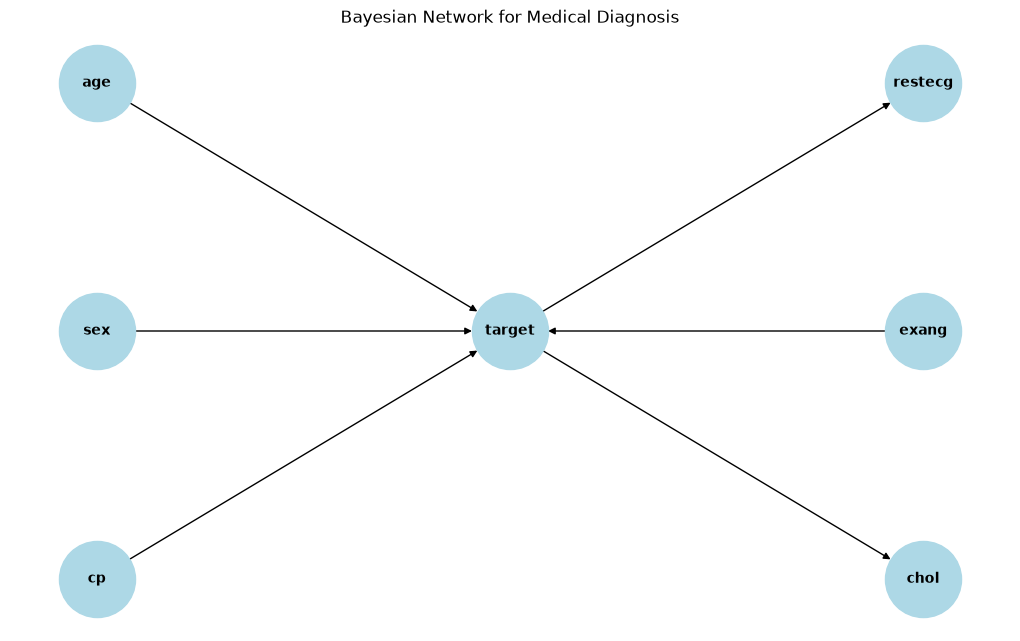

In [34]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 6))

pos = {
    "age": (0, 2),
    "sex": (0, 1),
    "cp": (0, 0),
    "target": (2, 1),
    "restecg": (4, 2),
    "exang": (4, 1),  # Added missing position for exang
    "chol": (4, 0),
}

nx.draw(
    model,
    pos=pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=True,
)

plt.title("Bayesian Network for Medical Diagnosis")
plt.show()

In [36]:
from pgmpy.inference import VariableElimination

print("\n" + "=" * 50)
print("Bayesian Network Inference")
print("=" * 50)

inference = VariableElimination(model)

print("\nQuery 1: Prior Probability of Target")
q1 = inference.query(variables=["target"])
print(q1)


Bayesian Network Inference

Query 1: Prior Probability of Target
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.6908 |
+-----------+---------------+
| target(1) |        0.3092 |
+-----------+---------------+


In [37]:
evidence = {
    "age": 2,
    "sex": 1,
    "cp": 2}

print(
    "\nQuery 2: Probability of Target "
    "Given Patient Information")

try:

    result = inference.query(
        variables=["target"],
        evidence=evidence)

    print("\nMedical Diagnosis Prediction")
    print("Evidence:", evidence)
    print(result)

except Exception as e:

    print("\nInference could not be performed.")
    print("Reason:", e)




Query 2: Probability of Target Given Patient Information

Medical Diagnosis Prediction
Evidence: {'age': 2, 'sex': 1, 'cp': 2}
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.6634 |
+-----------+---------------+
| target(1) |        0.3366 |
+-----------+---------------+


In [38]:
print(
    "\nQuery 3: Given restecg = 1, "
    "What is P(target)?")

try:

    result_3 = inference.query(
        variables=["target"],
        evidence={"restecg": 1})

    print(result_3)

except Exception as e:

    print("Reason:", e)





Query 3: Given restecg = 1, What is P(target)?
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.7328 |
+-----------+---------------+
| target(1) |        0.2672 |
+-----------+---------------+


In [40]:
print(
    "\nQuery 4: Given chol = 4, "
    "What is P(target)?")

try:

    result_4 = inference.query(
        variables=["target"],
        evidence={"chol": 4})

    print(result_4)

except Exception as e:

    print("Reason:", e)




Query 4: Given chol = 4, What is P(target)?
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        1.0000 |
+-----------+---------------+
| target(1) |        0.0000 |
+-----------+---------------+


In [41]:
print("\nDiagnosis Inference Complete.")




Diagnosis Inference Complete.
